Columns in file:
['Sample_ID', 'Sludge_%', 'Plasticizer_%', 'Density', 'sigma_m_MPa', 'sigma_c_mean_MPa']


,Sample_ID,Sludge_%,Plasticizer_%,Density,sigma_m_MPa,sigma_c_mean_MPa
0,C1,0.0,0.0,0.002070,15.058,73.351
1,C2,0.0,0.0,0.002122,13.920,77.499
2,C3,0.0,0.0,0.002108,15.412,79.204
3,1,1.0,0.0,0.002097,11.896,70.210
4,2,1.0,0.0,0.002116,13.340,69.879
5,3,1.0,0.0,0.002119,14.825,84.261
6,4,1.0,0.0,0.002125,11.542,80.884
7,5,2.5,0.0,0.002117,15.683,79.897
8,6,2.5,0.0,0.002085,15.790,84.307
9,7,2.5,0.0,0.002093,15.307,80.747



Best ANN hyperparameters:
regressor__ann__activation: tanh
regressor__ann__alpha: 0.1
regressor__ann__hidden_layer_sizes: (4,)
regressor__ann__solver: lbfgs

ANN LOOCV Metrics:


,Target,R2,RMSE,MAE,MAPE_%
0,sigma_m_MPa,0.850994,1.281886,1.114365,10.544847
1,sigma_c_mean_MPa,0.913441,4.414148,3.411789,5.131779


,Sample_ID,Sludge_%,Plasticizer_%,Density,sigma_m_MPa,sigma_c_mean_MPa,sigma_m_pred_ANN_LOOCV,sigma_c_pred_ANN_LOOCV,sigma_m_error,sigma_c_error,sigma_m_error_%,sigma_c_error_%
0,C1,0.0,0.0,0.002070,15.058,73.351,14.245211,79.574805,0.812789,-6.223805,5.397723,-8.484963
1,C2,0.0,0.0,0.002122,13.920,77.499,14.517066,79.669982,-0.597066,-2.170982,-4.289268,-2.801303
2,C3,0.0,0.0,0.002108,15.412,79.204,14.315746,79.414019,1.096254,-0.210019,7.112991,-0.265163
3,1,1.0,0.0,0.002097,11.896,70.210,14.589876,79.820890,-2.693876,-9.610890,-22.645225,-13.688777
4,2,1.0,0.0,0.002116,13.340,69.879,14.480387,80.105679,-1.140387,-10.226679,-8.548628,-14.634839
5,3,1.0,0.0,0.002119,14.825,84.261,14.347641,78.916583,0.477359,5.344417,3.219962,6.342694
6,4,1.0,0.0,0.002125,11.542,80.884,14.697430,79.328906,-3.155430,1.555094,-27.338679,1.922623
7,5,2.5,0.0,0.002117,15.683,79.897,14.133523,78.968771,1.549477,0.928229,9.879980,1.161782
8,6,2.5,0.0,0.002085,15.790,84.307,13.929238,77.986739,1.860762,6.320261,11.784431,7.496722
9,7,2.5,0.0,0.002093,15.307,80.747,14.068081,78.696927,1.238919,2.050073,8.093806,2.538885


,rank_test_score,mean_test_score,std_test_score,param_regressor__ann__hidden_layer_sizes,param_regressor__ann__activation,param_regressor__ann__solver,param_regressor__ann__alpha,mean_normalized_error
70,1,-0.076072,0.038937,"(4,)",tanh,lbfgs,0.1000,0.076072
30,2,-0.077444,0.039510,"(4,)",relu,lbfgs,0.1000,0.077444
72,3,-0.077503,0.040743,"(6,)",tanh,lbfgs,0.1000,0.077503
78,4,-0.077795,0.040538,"(12,)",tanh,lbfgs,0.1000,0.077795
0,5,-0.078132,0.041712,"(4,)",relu,lbfgs,0.0001,0.078132
36,6,-0.078438,0.040947,"(10,)",relu,lbfgs,0.1000,0.078438
74,7,-0.079093,0.040706,"(8,)",tanh,lbfgs,0.1000,0.079093
26,8,-0.079219,0.041730,"(10,)",relu,lbfgs,0.0100,0.079219
38,9,-0.079289,0.041179,"(12,)",relu,lbfgs,0.1000,0.079289
20,10,-0.080441,0.040125,"(4,)",relu,lbfgs,0.0100,0.080441


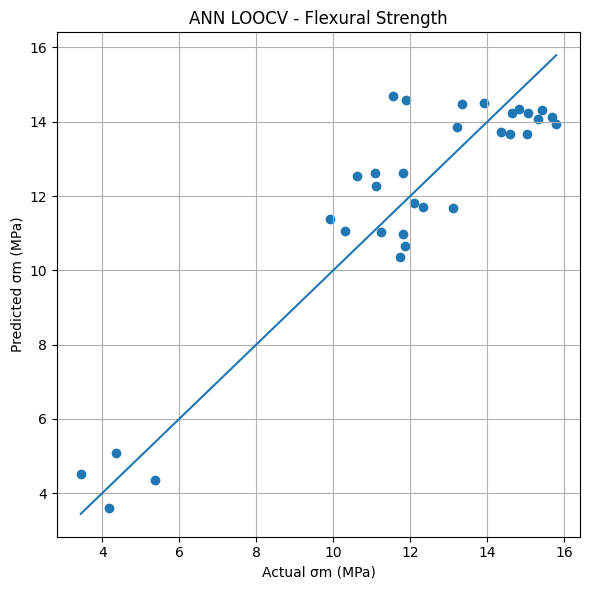

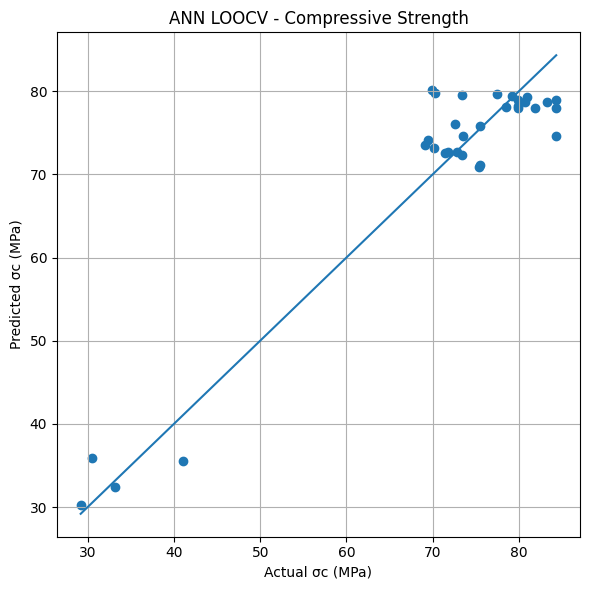

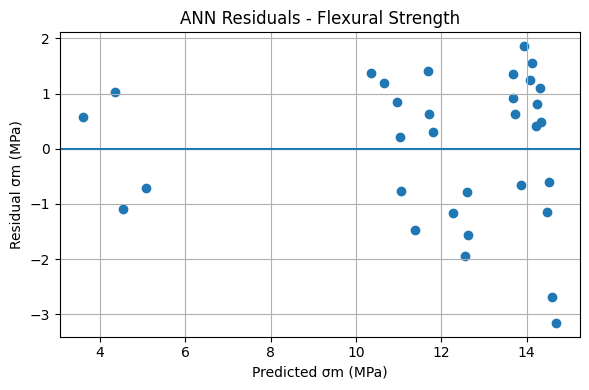

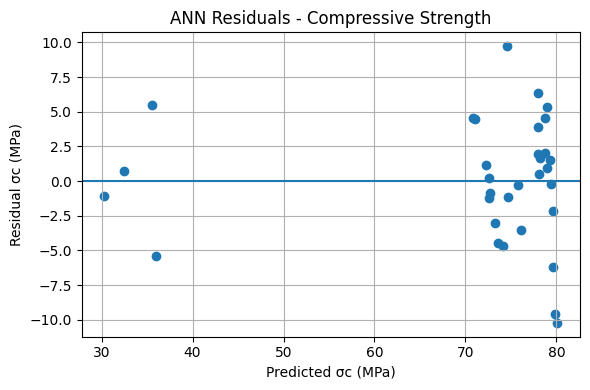


Files saved:
1. ANN_publication_results.xlsx
2. ANN_actual_vs_pred_sigma_m.png
3. ANN_actual_vs_pred_sigma_c.png
4. ANN_residual_sigma_m.png
5. ANN_residual_sigma_c.png
6. ANN_final_model.pkl


In [ ]:
# ============================================================
# Publication-ready ANN model
# Input file: Final.xlsx
# Inputs: Sludge %, Plasticizer %, Density
# Outputs: sigma_m, mean sigma_c
# Validation: LOOCV
# Hyperparameter tuning: Grid search
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib

from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ------------------------------------------------------------
# 1. Import Excel file
# ------------------------------------------------------------

data = pd.read_excel("Final.xlsx")
data.columns = data.columns.astype(str).str.strip()

# Rename columns if your Excel uses readable names
rename_map = {
    "Sample ID": "Sample_ID",
    "Sample_ID": "Sample_ID",

    "Sludge %": "Sludge_%",
    "Sludge_%": "Sludge_%",

    "Plasticizer %": "Plasticizer_%",
    "Plasticizer_%": "Plasticizer_%",

    "Density": "Density",

    "σm Flexural (MPa)": "sigma_m_MPa",
    "sigma_m_MPa": "sigma_m_MPa",

    "mean σc Compression (MPa)": "sigma_c_mean_MPa",
    "sigma_c_mean_MPa": "sigma_c_mean_MPa"
}

data = data.rename(columns=rename_map)

print("Columns in file:")
print(data.columns.tolist())

# ------------------------------------------------------------
# 2. Define inputs and outputs
# ------------------------------------------------------------

X_cols = ["Sludge_%", "Plasticizer_%", "Density"]
y_cols = ["sigma_m_MPa", "sigma_c_mean_MPa"]

required_cols = ["Sample_ID"] + X_cols + y_cols
missing_cols = [col for col in required_cols if col not in data.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing columns in Excel file: {missing_cols}")

data = data[required_cols].dropna().reset_index(drop=True)

X = data[X_cols].values
y = data[y_cols].values

display(data)

# ------------------------------------------------------------
# 3. Custom scoring function for multi-output ANN
# Lower normalized error is better
# ------------------------------------------------------------

y_range = np.ptp(y, axis=0)
y_range[y_range == 0] = 1

def neg_mean_normalized_error(y_true, y_pred):
    abs_error = np.abs(y_true - y_pred)
    normalized_error = abs_error / y_range
    return -np.mean(normalized_error)

ann_scorer = make_scorer(neg_mean_normalized_error, greater_is_better=True)

# ------------------------------------------------------------
# 4. Build ANN pipeline with input and output scaling
# ------------------------------------------------------------

ann = MLPRegressor(
    max_iter=10000,
    random_state=42
)

x_pipeline = Pipeline([
    ("x_scaler", StandardScaler()),
    ("ann", ann)
])

model = TransformedTargetRegressor(
    regressor=x_pipeline,
    transformer=StandardScaler()
)

# ------------------------------------------------------------
# 5. Hyperparameter grid
# ------------------------------------------------------------

param_grid = {
    "regressor__ann__hidden_layer_sizes": [
        (4,), (6,), (8,), (10,), (12,)
    ],
    "regressor__ann__activation": ["relu", "tanh"],
    "regressor__ann__solver": ["lbfgs", "adam"],
    "regressor__ann__alpha": [0.0001, 0.001, 0.01, 0.1]
}

loo = LeaveOneOut()

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=ann_scorer,
    cv=loo,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X, y)

best_model = grid.best_estimator_
best_params = grid.best_params_

print("\nBest ANN hyperparameters:")
for key, value in best_params.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# 6. LOOCV prediction using best ANN configuration
# ------------------------------------------------------------

y_pred_loocv = cross_val_predict(
    best_model,
    X,
    y,
    cv=loo,
    n_jobs=-1
)

# ------------------------------------------------------------
# 7. Metrics
# ------------------------------------------------------------

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics_rows = []

for i, target in enumerate(y_cols):
    y_true_i = y[:, i]
    y_pred_i = y_pred_loocv[:, i]

    r2 = r2_score(y_true_i, y_pred_i)
    mae = mean_absolute_error(y_true_i, y_pred_i)
    rmse = np.sqrt(mean_squared_error(y_true_i, y_pred_i))
    mape_value = mape(y_true_i, y_pred_i)

    metrics_rows.append({
        "Target": target,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape_value
    })

metrics_df = pd.DataFrame(metrics_rows)

print("\nANN LOOCV Metrics:")
display(metrics_df)

# ------------------------------------------------------------
# 8. Prediction results table
# ------------------------------------------------------------

predictions_df = data.copy()

predictions_df["sigma_m_pred_ANN_LOOCV"] = y_pred_loocv[:, 0]
predictions_df["sigma_c_pred_ANN_LOOCV"] = y_pred_loocv[:, 1]

predictions_df["sigma_m_error"] = (
    predictions_df["sigma_m_MPa"] - predictions_df["sigma_m_pred_ANN_LOOCV"]
)

predictions_df["sigma_c_error"] = (
    predictions_df["sigma_c_mean_MPa"] - predictions_df["sigma_c_pred_ANN_LOOCV"]
)

predictions_df["sigma_m_error_%"] = (
    predictions_df["sigma_m_error"] / predictions_df["sigma_m_MPa"]
) * 100

predictions_df["sigma_c_error_%"] = (
    predictions_df["sigma_c_error"] / predictions_df["sigma_c_mean_MPa"]
) * 100

display(predictions_df)

# ------------------------------------------------------------
# 9. Grid search results
# ------------------------------------------------------------

grid_results_df = pd.DataFrame(grid.cv_results_)

grid_results_clean = grid_results_df[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_regressor__ann__hidden_layer_sizes",
        "param_regressor__ann__activation",
        "param_regressor__ann__solver",
        "param_regressor__ann__alpha"
    ]
].copy()

grid_results_clean = grid_results_clean.sort_values("rank_test_score")
grid_results_clean["mean_normalized_error"] = -grid_results_clean["mean_test_score"]

display(grid_results_clean.head(10))

# ------------------------------------------------------------
# 10. Plot data for Excel
# ------------------------------------------------------------

plot_sigma_m = pd.DataFrame({
    "Sample_ID": data["Sample_ID"],
    "Actual_sigma_m_MPa": y[:, 0],
    "Predicted_sigma_m_MPa": y_pred_loocv[:, 0],
    "Error_sigma_m": predictions_df["sigma_m_error"],
    "Error_sigma_m_%": predictions_df["sigma_m_error_%"]
})

plot_sigma_c = pd.DataFrame({
    "Sample_ID": data["Sample_ID"],
    "Actual_sigma_c_MPa": y[:, 1],
    "Predicted_sigma_c_MPa": y_pred_loocv[:, 1],
    "Error_sigma_c": predictions_df["sigma_c_error"],
    "Error_sigma_c_%": predictions_df["sigma_c_error_%"]
})

sigma_m_min = min(plot_sigma_m["Actual_sigma_m_MPa"].min(), plot_sigma_m["Predicted_sigma_m_MPa"].min())
sigma_m_max = max(plot_sigma_m["Actual_sigma_m_MPa"].max(), plot_sigma_m["Predicted_sigma_m_MPa"].max())

sigma_c_min = min(plot_sigma_c["Actual_sigma_c_MPa"].min(), plot_sigma_c["Predicted_sigma_c_MPa"].min())
sigma_c_max = max(plot_sigma_c["Actual_sigma_c_MPa"].max(), plot_sigma_c["Predicted_sigma_c_MPa"].max())

parity_sigma_m = pd.DataFrame({
    "Parity_x": [sigma_m_min, sigma_m_max],
    "Parity_y": [sigma_m_min, sigma_m_max]
})

parity_sigma_c = pd.DataFrame({
    "Parity_x": [sigma_c_min, sigma_c_max],
    "Parity_y": [sigma_c_min, sigma_c_max]
})

# ------------------------------------------------------------
# 11. Actual vs predicted plots
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(plot_sigma_m["Actual_sigma_m_MPa"], plot_sigma_m["Predicted_sigma_m_MPa"])
plt.plot([sigma_m_min, sigma_m_max], [sigma_m_min, sigma_m_max])
plt.xlabel("Actual σm (MPa)")
plt.ylabel("Predicted σm (MPa)")
plt.title("ANN LOOCV - Flexural Strength")
plt.grid(True)
plt.tight_layout()
plt.savefig("ANN_actual_vs_pred_sigma_m.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(plot_sigma_c["Actual_sigma_c_MPa"], plot_sigma_c["Predicted_sigma_c_MPa"])
plt.plot([sigma_c_min, sigma_c_max], [sigma_c_min, sigma_c_max])
plt.xlabel("Actual σc (MPa)")
plt.ylabel("Predicted σc (MPa)")
plt.title("ANN LOOCV - Compressive Strength")
plt.grid(True)
plt.tight_layout()
plt.savefig("ANN_actual_vs_pred_sigma_c.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 12. Residual plots
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))
plt.scatter(plot_sigma_m["Predicted_sigma_m_MPa"], plot_sigma_m["Error_sigma_m"])
plt.axhline(0)
plt.xlabel("Predicted σm (MPa)")
plt.ylabel("Residual σm (MPa)")
plt.title("ANN Residuals - Flexural Strength")
plt.grid(True)
plt.tight_layout()
plt.savefig("ANN_residual_sigma_m.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(plot_sigma_c["Predicted_sigma_c_MPa"], plot_sigma_c["Error_sigma_c"])
plt.axhline(0)
plt.xlabel("Predicted σc (MPa)")
plt.ylabel("Residual σc (MPa)")
plt.title("ANN Residuals - Compressive Strength")
plt.grid(True)
plt.tight_layout()
plt.savefig("ANN_residual_sigma_c.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 13. Train final ANN model on all data
# ------------------------------------------------------------

final_ann_model = best_model
final_ann_model.fit(X, y)

joblib.dump(
    {
        "model": final_ann_model,
        "X_cols": X_cols,
        "y_cols": y_cols,
        "best_params": best_params
    },
    "ANN_final_model.pkl"
)

# ------------------------------------------------------------
# 14. Export all outputs to Excel
# ------------------------------------------------------------

best_params_df = pd.DataFrame({
    "Hyperparameter": list(best_params.keys()),
    "Selected_value": [str(v) for v in best_params.values()]
})

with pd.ExcelWriter("ANN_publication_results.xlsx", engine="openpyxl") as writer:
    data.to_excel(writer, sheet_name="Clean_Data", index=False)
    best_params_df.to_excel(writer, sheet_name="Best_Hyperparameters", index=False)
    metrics_df.to_excel(writer, sheet_name="LOOCV_Metrics", index=False)
    predictions_df.to_excel(writer, sheet_name="LOOCV_Predictions", index=False)
    grid_results_clean.to_excel(writer, sheet_name="Grid_Search_Results", index=False)
    plot_sigma_m.to_excel(writer, sheet_name="Plot_Data_sigma_m", index=False)
    parity_sigma_m.to_excel(writer, sheet_name="Parity_sigma_m", index=False)
    plot_sigma_c.to_excel(writer, sheet_name="Plot_Data_sigma_c", index=False)
    parity_sigma_c.to_excel(writer, sheet_name="Parity_sigma_c", index=False)

print("\nFiles saved:")
print("1. ANN_publication_results.xlsx")
print("2. ANN_actual_vs_pred_sigma_m.png")
print("3. ANN_actual_vs_pred_sigma_c.png")
print("4. ANN_residual_sigma_m.png")
print("5. ANN_residual_sigma_c.png")
print("6. ANN_final_model.pkl")